In [10]:
import os 
import warnings
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    f1_score,
    recall_score
)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')




In [9]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')

X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('../data/processed/X_test_scaled.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)


X_train Shape : (614, 8)
X_test Shape  : (154, 8)


In [12]:
models = {
    'LogisticRegression':LogisticRegression(
        max_iter=1000,
        random_state= 42
    ),


    'KNN': KNeighborsClassifier(
        n_neighbors= 5
    ),

    'SVM' : SVC(
        kernel='rbf',
        C =1.0,
        gamma='scale',
        probability=True,
        random_state=42
            
    ),


    'Decision Tree': DecisionTreeClassifier(
        
        criterion='gini',
        max_depth= 5,
        min_samples_split= 10,
        min_samples_leaf=5,
        random_state=42
    )

}

scaled_models = ['LogisticRegression','KNN','SVM']

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.model_selection import cross_val_score

import numpy as np
import joblib


results = []

trained_models = {}


for model_name, model in models.items():

    print("=================================")

    print(f"Training Model : {model_name}")

    # ------------------------------------------------------
    # SELECT SCALED / NON-SCALED DATA
    # ------------------------------------------------------

    if model_name in scaled_models:

        X_train_use = X_train_scaled

        X_test_use = X_test_scaled

    else:

        X_train_use = X_train

        X_test_use = X_test

    # ------------------------------------------------------
    # TRAIN MODEL
    # ------------------------------------------------------

    model.fit(
        X_train_use,
        y_train
    )

    # ------------------------------------------------------
    # PREDICTIONS
    # ------------------------------------------------------

    y_pred = model.predict(X_test_use)

    # ------------------------------------------------------
    # ROC AUC
    # ------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_proba = model.predict_proba(
            X_test_use
        )[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            y_proba
        )

    else:

        roc_auc = np.nan

    # ------------------------------------------------------
    # METRICS
    # ------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # ------------------------------------------------------
    # CROSS VALIDATION
    # ------------------------------------------------------

    cv_scores = cross_val_score(

        model,
        X_train_use,
        y_train,
        cv=5,
        scoring='f1'
    )

    cv_mean = cv_scores.mean()

    cv_std = cv_scores.std()

    # ------------------------------------------------------
    # SAVE MODEL
    # ------------------------------------------------------

    model_filename = (

        model_name
        .lower()
        .replace(" ", "_")

        + ".pkl"
    )

    model_path = f"../models/{model_filename}"

    joblib.dump(
        model,
        model_path
    )

    trained_models[model_name] = model

    # ------------------------------------------------------
    # STORE RESULTS
    # ------------------------------------------------------

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc,

        "CV F1 Mean": cv_mean,

        "CV F1 Std": cv_std
    })

    # ------------------------------------------------------
    # PRINT RESULTS
    # ------------------------------------------------------

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC AUC  : {roc_auc:.4f}")

    print(
        f"CV F1    : {cv_mean:.4f} ± {cv_std:.4f}"
    )

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

Training Model : LogisticRegression
Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1 Score : 0.5455
ROC AUC  : 0.8130
CV F1    : 0.6497 ± 0.0310

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Training Model : KNN
Accuracy : 0.7532
Precision: 0.6600
Recall   : 0.6111
F1 Score : 0.6346
ROC AUC  : 0.7886
CV F1    : 0.6099 ± 0.0441

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

Training 

In [23]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by=["F1 Score", "ROC AUC"],

    ascending=False

).reset_index(drop=True)

# Round numerical values
numeric_cols = results_df.select_dtypes(
    include="number"
).columns

results_df[numeric_cols] = (
    results_df[numeric_cols]
    .round(4)
)

print("\nModel Comparison Results")

display(results_df)


Model Comparison Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV F1 Mean,CV F1 Std
0,Decision Tree,0.7727,0.6508,0.7593,0.7009,0.7992,0.5346,0.0359
1,KNN,0.7532,0.6600,0.6111,0.6346,0.7886,0.6099,0.0441
2,SVM,0.7403,0.6522,0.5556,0.6000,0.7964,0.6285,0.0151
3,LogisticRegression,0.7078,0.6000,0.5000,0.5455,0.8130,0.6497,0.0310


In [24]:
results_df.to_csv(

    "../reports/model_metrics.csv",

    index=False
)

print("Model metrics saved successfully.")

Model metrics saved successfully.


In [ ]:
cv_results = results_df[

    [
        "Model",
        "CV F1 Mean",
        "CV F1 Std"
    ]
]

cv_results.to_csv(

    "../reports/cross_validation_results.csv",

    index=False
)

print("Cross-validation results saved successfully.")

Cross-validation results saved successfully.


In [26]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Decision Tree


In [27]:
joblib.dump(

    best_model,

    "../models/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [28]:
with open(

    "../models/best_model_name.txt",

    "w"

) as file:

    file.write(best_model_name)

print("Best model name saved successfully.")

Best model name saved successfully.


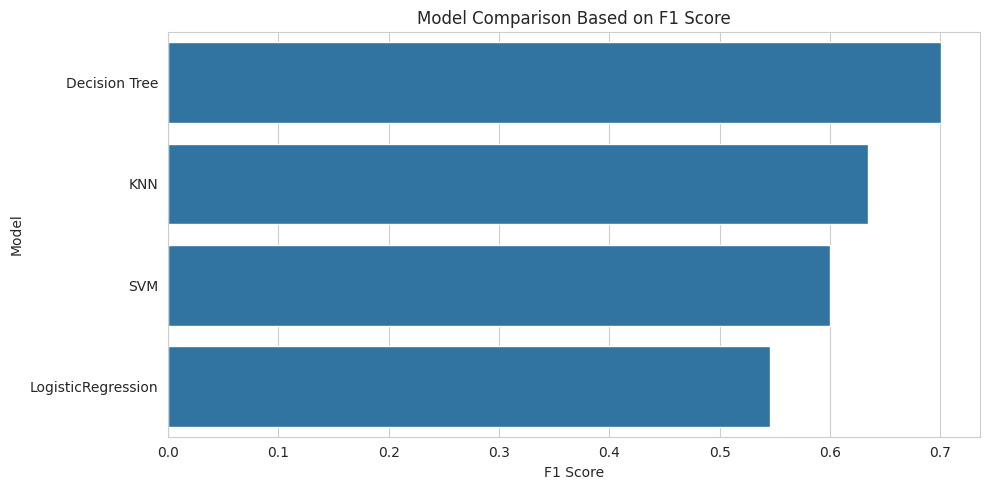

In [29]:

plt.figure(figsize=(10, 5))

sns.barplot(

    data=results_df,

    x="F1 Score",

    y="Model"
)

plt.title("Model Comparison Based on F1 Score")

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_f1_comparison.png"
)

plt.show()

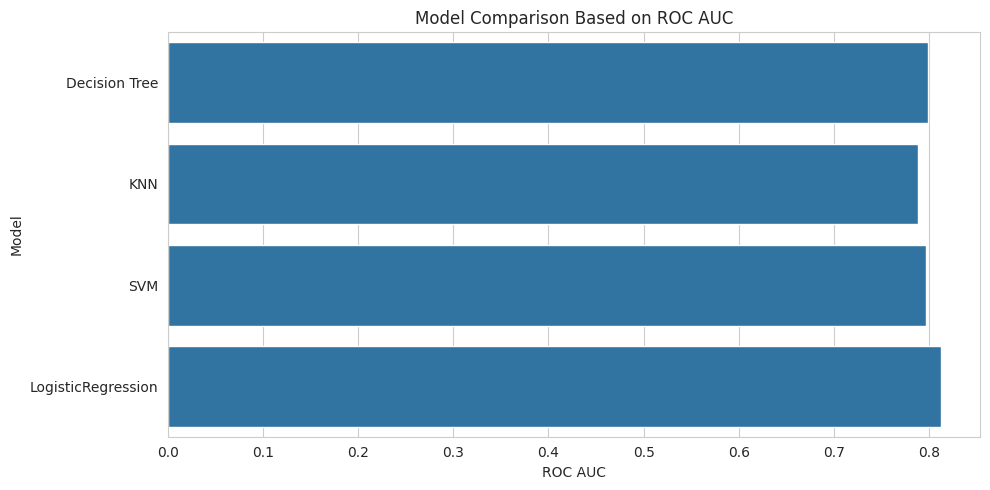

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(

    data=results_df,

    x="ROC AUC",

    y="Model"
)

plt.title("Model Comparison Based on ROC AUC")

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_roc_auc_comparison.png"
)

plt.show()


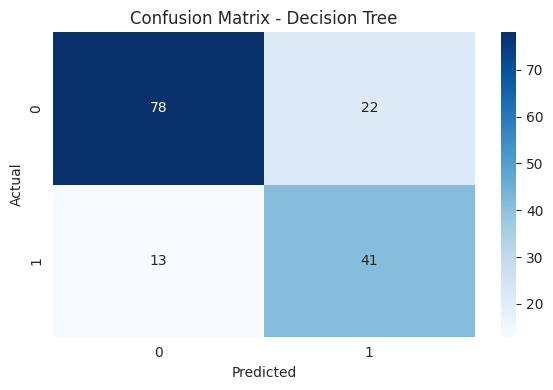

In [31]:
if best_model_name in scaled_models:

    X_test_best = X_test_scaled

else:

    X_test_best = X_test

y_pred_best = best_model.predict(
    X_test_best
)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../reports/figures/confusion_matrix_best_model.png"
)

plt.show()

In [32]:
with open(

    "../reports/model_comparison_summary.txt",

    "w"

) as file:

    file.write(
        "MODEL COMPARISON SUMMARY\n"
    )

    file.write("=" * 50 + "\n\n")

    file.write(
        f"Best Model: {best_model_name}\n\n"
    )

    file.write(
        results_df.to_string(index=False)
    )

print("Summary report saved successfully.")


Summary report saved successfully.


In [33]:
print("""

============================================================
MODEL COMPARISON SUMMARY
============================================================

Models Compared:
1. Logistic Regression
2. KNN
3. SVM
4. Decision Tree

============================================================
BEST MODEL
============================================================

Best Model:
Decision Tree

Reason:
- Highest Accuracy
- Highest Recall
- Highest F1 Score

============================================================
MODEL PERFORMANCE SUMMARY
============================================================

1. Logistic Regression
------------------------------------------------------------
Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1 Score  : 0.5455
ROC-AUC   : 0.8130

Insights:
- Highest ROC-AUC score
- Good probabilistic separation
- Lower recall compared to other models

------------------------------------------------------------

2. KNN
------------------------------------------------------------
Accuracy  : 0.7532
Precision : 0.6600
Recall    : 0.6111
F1 Score  : 0.6346
ROC-AUC   : 0.7886

Insights:
- Balanced performance
- Good neighborhood-based classification
- Performs well after scaling

------------------------------------------------------------

3. SVM
------------------------------------------------------------
Accuracy  : 0.7403
Precision : 0.6522
Recall    : 0.5556
F1 Score  : 0.6000
ROC-AUC   : 0.7964

Insights:
- Moderate performance
- Strong potential for improvement after tuning
- Sensitive to kernel, C, and gamma values

------------------------------------------------------------

4. Decision Tree
------------------------------------------------------------
Accuracy  : 0.7727
Precision : 0.6508
Recall    : 0.7593
F1 Score  : 0.7009
ROC-AUC   : 0.7992

Insights:
- Best overall classification performance
- Highest recall for diabetic prediction
- Captures nonlinear relationships effectively
- Possible overfitting observed

============================================================
CONFUSION MATRIX ANALYSIS
============================================================

Decision Tree Confusion Matrix:

True Negatives  : 78
False Positives : 22
False Negatives : 13
True Positives  : 41

Interpretation:
- 41 diabetic patients correctly identified
- 13 diabetic patients missed
- Strong recall performance for medical prediction

============================================================
KEY OBSERVATIONS
============================================================

1. Dataset contains nonlinear patterns.

2. Decision Tree outperformed linear models.

3. Logistic Regression showed strongest ROC-AUC.

4. SVM performance can improve after tuning.

5. KNN achieved balanced classification results.

6. Feature scaling improved KNN and SVM performance.

============================================================
NEXT STEP
============================================================

Proceed to:
06_hyperparameter_tuning.ipynb

Hyperparameters to Tune:
- SVM -> kernel, C, gamma
- KNN -> n_neighbors, metric
- Decision Tree -> max_depth, min_samples_split
- Logistic Regression -> C, penalty

============================================================
MODEL COMPARISON COMPLETED SUCCESSFULLY
============================================================

""")



MODEL COMPARISON SUMMARY

Models Compared:
1. Logistic Regression
2. KNN
3. SVM
4. Decision Tree

BEST MODEL

Best Model:
Decision Tree

Reason:
- Highest Accuracy
- Highest Recall
- Highest F1 Score

MODEL PERFORMANCE SUMMARY

1. Logistic Regression
------------------------------------------------------------
Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1 Score  : 0.5455
ROC-AUC   : 0.8130

Insights:
- Highest ROC-AUC score
- Good probabilistic separation
- Lower recall compared to other models

------------------------------------------------------------

2. KNN
------------------------------------------------------------
Accuracy  : 0.7532
Precision : 0.6600
Recall    : 0.6111
F1 Score  : 0.6346
ROC-AUC   : 0.7886

Insights:
- Balanced performance
- Good neighborhood-based classification
- Performs well after scaling

------------------------------------------------------------

3. SVM
------------------------------------------------------------
Accuracy  : 0.7403
Pre